# Requisito 3 - primal-dual con budget, versione base

Piu' campagne, vincolo di budget, full feedback. L'ambiente stocastico e' quello del requisito 2; in piu' c'e' un ambiente altamente non stazionario con una sequenza non stocastica di massimi bid concorrenti.

L'algoritmo e' il metodo primal-dual del corso esteso alle super-azioni:

- primal: Hedge sulle super-azioni ammissibili;
- dual: OGD proiettato sul moltiplicatore del budget, aggiornato con il costo atteso c_t · x_t;
- stop sul budget: quando il residuo non copre il costo massimo di un round si gioca la super-azione nulla (generalizza il controllo `budget < 1` del caso a costi in [0,1]).

In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, stats

SEED = 17
T = 3000
TRIALS = 10
B = 700.0
RHO = B / T

# stessa istanza del requisito 2
BID_GRID = np.linspace(0.0, 1.0, 11)
VALUES = np.array([0.95, 0.85, 0.78, 0.90])
CONFLICT_EDGES = [(0, 1), (1, 2), (2, 3)]
N_CAMPAIGNS = len(VALUES)

# ambiente stocastico del requisito 2: marginali Beta per campagna con fattore comune
BETA_PARAMS = [(2.0, 5.0), (2.8, 3.8), (3.5, 3.0), (2.3, 4.0)]
CORR_P = 0.3

np.set_printoptions(precision=3, suppress=True)

## Super-azioni

Un bid per campagna, nessuna coppia in conflitto attiva insieme; i bid sopra la valutazione sono dominati e vengono tolti, come nel requisito 2.

In [2]:
grids = [BID_GRID[BID_GRID <= VALUES[i]] for i in range(N_CAMPAIGNS)]

superactions = []
for bids in itertools.product(*grids):
    bids = np.array(bids)
    if any(bids[i] > 0 and bids[j] > 0 for i, j in CONFLICT_EDGES):
        continue
    superactions.append(bids)

SA_BIDS = np.array(superactions)          # (K, N_CAMPAIGNS)
SA_BID_SUMS = SA_BIDS.sum(axis=1)
K = len(SA_BIDS)
NULL_IDX = 0
assert np.all(SA_BIDS[NULL_IDX] == 0)

MAX_ROUND_REWARD = float(VALUES.sum())
MAX_ROUND_COST = float(SA_BID_SUMS.max())

print(f'K = {K} super-azioni, costo massimo per round = {MAX_ROUND_COST:.2f}')

K = 250 super-azioni, costo massimo per round = 1.80


## Ambienti

I threshold m_(i,t) sono generati in anticipo (sequenza oblivious). Con full feedback dopo ogni round si conoscono reward e costo controfattuali di ogni super-azione, quindi l'ambiente restituisce i vettori completi f_t e c_t.

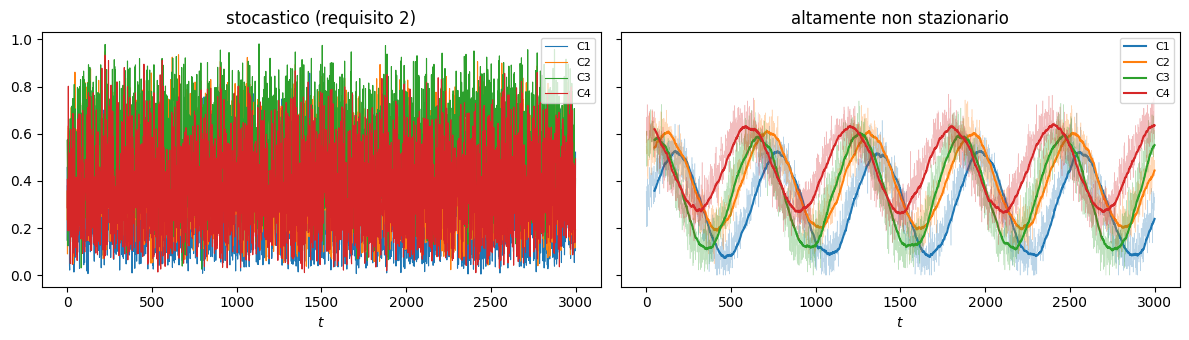

In [3]:
def build_stochastic_sequence(horizon, seed):
    # ambiente stocastico del requisito 2: marginali Beta con fattore comune
    # (in una frazione CORR_P dei round tutte le campagne condividono lo stesso quantile)
    rng = np.random.default_rng(seed)
    u = rng.uniform(size=(horizon, N_CAMPAIGNS))
    common = rng.uniform(size=horizon)
    shared = rng.uniform(size=horizon) < CORR_P
    u[shared] = common[shared, None]
    M = np.zeros((horizon, N_CAMPAIGNS))
    for i, (a, b) in enumerate(BETA_PARAMS):
        M[:, i] = stats.beta.ppf(u[:, i], a, b)
    return M


def build_nonstationary_sequence(horizon, seed):
    # sequenza non stocastica: ogni threshold segue una sinusoide veloce con fase propria,
    # cosi le campagne convenienti ruotano nel tempo; un piccolo rumore evita la periodicita' esatta
    t = np.arange(horizon) / horizon
    base = np.array([0.30, 0.40, 0.35, 0.45])
    amp = np.array([0.22, 0.20, 0.24, 0.18])
    phase = np.array([0.0, 0.6, 1.2, 1.8])
    M = base + amp * np.sin(2 * np.pi * 5 * t[:, None] + phase)
    M = M + np.random.default_rng(seed).normal(0, 0.05, M.shape)
    return np.clip(M, 0.0, 1.0)


def build_sequence(regime, horizon, seed):
    if regime == 'stochastic':
        return build_stochastic_sequence(horizon, seed)
    return build_nonstationary_sequence(horizon, seed)


def feedback_matrices(M):
    # full feedback: reward e costo controfattuali di ogni super-azione, matrici (T, K)
    wins = SA_BIDS[None, :, :] >= M[:, None, :]
    F = ((VALUES - SA_BIDS)[None, :, :] * wins).sum(axis=2)
    C = (SA_BIDS[None, :, :] * wins).sum(axis=2)
    return F, C


w = 50   # finestra della media mobile, per vedere la struttura sotto il rumore
Mst = build_sequence('stochastic', T, SEED)
Mns = build_sequence('nonstationary', T, SEED)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
for i in range(N_CAMPAIGNS):
    axes[0].plot(Mst[:, i], lw=0.8, label=f'C{i+1}')
    axes[1].plot(Mns[:, i], lw=0.4, alpha=0.3, color=f'C{i}')
    roll = np.convolve(Mns[:, i], np.ones(w) / w, mode='valid')
    axes[1].plot(np.arange(w - 1, T), roll, lw=1.5, color=f'C{i}', label=f'C{i+1}')
axes[0].set_title('stocastico (requisito 2)')
axes[1].set_title('altamente non stazionario')
for ax in axes:
    ax.set_xlabel('$t$')
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## Clairvoyant

Migliore distribuzione fissa in hindsight che rispetta il vincolo di budget in media, calcolata con un LP. Nei grafici confronto contro OPT pieno; nella teoria adversarial la garanzia vale contro il benchmark piu' debole rho·OPT.

In [4]:
def compute_clairvoyant(f_avg, c_avg, rho):
    res = optimize.linprog(-f_avg, A_ub=[c_avg], b_ub=[rho],
                           A_eq=[np.ones(K)], b_eq=[1], bounds=(0, 1), method='highs')
    x = np.maximum(res.x, 0)
    x = x / x.sum()
    return x, f_avg @ x, c_avg @ x

## Agenti

Hedge lavora sulla Lagrangiana L_t(a) = f_t(a) - lambda_t (c_t(a) - rho). Hedge richiede loss in [0,1] ma L dipende da lambda_t, che varia: la riporto in [0,1] con bound fissi calcolati sul caso peggiore (lambda_max = 1/rho). Il range che ne esce e' largo (~11), quindi il learning rate effettivo si riduce di altrettanto: e' il prezzo di una normalizzazione valida per tutto l'orizzonte.

Learning rate come nel corso: eta_Hedge = sqrt(log(K)/T), eta_OGD = 1/sqrt(T). Il duale si aggiorna con il costo atteso c_t · x_t, il budget scende con il costo realizzato c_t(a_t).

`RandomAgent` e' un riferimento: uniforme sulle super-azioni pagabili.

In [5]:
class HedgeAgent:
    def __init__(self, K, learning_rate):
        self.K = K
        self.learning_rate = learning_rate
        self.weights = np.ones(K)
        self.x_t = np.ones(K) / K

    def choose_distribution(self):
        self.x_t = self.weights / self.weights.sum()
        return self.x_t

    def update(self, l_t):
        self.weights *= np.exp(-self.learning_rate * l_t)
        self.weights /= self.weights.max()   # riscala i pesi, x_t non cambia

In [6]:
class PrimalDualPacingAgent:
    def __init__(self, K, B, T, seed):
        self.hedge = HedgeAgent(K, np.sqrt(np.log(K) / T))
        self.budget = B
        self.rho = B / T
        self.eta = 1 / np.sqrt(T)
        self.lmbd = 1.0
        self.rng = np.random.default_rng(seed)
        # bound fissi per riportare L in [0,1], calcolati con lambda_max = 1/rho
        self.L_up = MAX_ROUND_REWARD + (1 / self.rho) * self.rho
        self.L_low = -(1 / self.rho) * (MAX_ROUND_COST - self.rho)
        self.x_t = np.ones(K) / K
        self.a_t = NULL_IDX

    def pull_arm(self):
        # stop: se il budget non copre il round peggiore, gioco la super-azione nulla
        if self.budget < MAX_ROUND_COST:
            self.x_t = np.zeros(K)
            self.x_t[NULL_IDX] = 1.0
            self.a_t = NULL_IDX
            return self.a_t
        self.x_t = self.hedge.choose_distribution()
        self.a_t = self.rng.choice(K, p=self.x_t)
        return self.a_t

    def update(self, f_t, c_t):
        L = f_t - self.lmbd * (c_t - self.rho)
        rescaled_L = (L - self.L_low) / (self.L_up - self.L_low)
        self.hedge.update(1 - rescaled_L)          # Hedge massimizza L
        expected_cost = c_t @ self.x_t
        actual_cost = c_t[self.a_t]
        self.lmbd = np.clip(self.lmbd - self.eta * (self.rho - expected_cost),
                            0, 1 / self.rho)
        self.budget -= actual_cost


class RandomAgent:
    def __init__(self, K, B, seed):
        self.budget = B
        self.rng = np.random.default_rng(seed)
        self.x_t = np.ones(K) / K
        self.a_t = NULL_IDX
        self.lmbd = np.nan

    def pull_arm(self):
        feasible = SA_BID_SUMS <= self.budget
        feasible[NULL_IDX] = True
        self.x_t = feasible / feasible.sum()
        self.a_t = self.rng.choice(K, p=self.x_t)
        return self.a_t

    def update(self, f_t, c_t):
        self.budget -= c_t[self.a_t]

## Simulazione

L'agente sceglie l'azione prima di vedere i threshold del round; i vettori full-feedback entrano solo nell'update. Il pseudo-regret confronta il reward atteso f_t · x_t con il reward istantaneo della migliore distribuzione fissa in hindsight.

In [7]:
def run_trial(regime, agent_kind, horizon, budget, seed):
    M = build_sequence(regime, horizon, seed)
    F, C = feedback_matrices(M)
    rho = budget / horizon
    clairvoyant_x, _, _ = compute_clairvoyant(F.mean(axis=0), C.mean(axis=0), rho)
    clairvoyant_rewards = F @ clairvoyant_x

    if agent_kind == 'primal_dual':
        agent = PrimalDualPacingAgent(K, budget, horizon, seed + 10_000)
    else:
        agent = RandomAgent(K, budget, seed + 20_000)

    exp_rewards = np.zeros(horizon)
    actual_rewards = np.zeros(horizon)
    actual_costs = np.zeros(horizon)
    lmbds = np.zeros(horizon)

    for t in range(horizon):
        a_t = agent.pull_arm()
        f_t, c_t = F[t], C[t]
        exp_rewards[t] = f_t @ agent.x_t
        actual_rewards[t] = f_t[a_t]
        actual_costs[t] = c_t[a_t]
        lmbds[t] = agent.lmbd
        agent.update(f_t, c_t)

    return {
        'pseudo_regret': clairvoyant_rewards - exp_rewards,
        'actual_reward': actual_rewards,
        'actual_cost': actual_costs,
        'lambda': lmbds,
        'clairvoyant_reward': clairvoyant_rewards,
    }


results = {}
for regime in ['stochastic', 'nonstationary']:
    results[regime] = {}
    for agent_kind in ['primal_dual', 'random']:
        runs = []
        for trial in range(TRIALS):
            seed = SEED + 1000 * trial + (100_000 if regime == 'nonstationary' else 0)
            runs.append(run_trial(regime, agent_kind, T, B, seed))
        results[regime][agent_kind] = runs

print('fatto')

fatto


## Risultati

In [8]:
print(f'{"regime":<15}{"agente":<13}{"reward":>9}{"regret/T":>10}{"spesa":>9}{"violazione":>12}')
for regime in results:
    for agent_kind, runs in results[regime].items():
        reward = np.mean([r['actual_reward'].sum() for r in runs])
        regret = np.mean([r['pseudo_regret'].sum() for r in runs]) / T
        spend = np.mean([r['actual_cost'].sum() for r in runs])
        violation = max(0.0, max(r['actual_cost'].sum() for r in runs) - B)
        print(f'{regime:<15}{agent_kind:<13}{reward:>9.1f}{regret:>10.3f}{spend:>9.1f}{violation:>12.2f}')

regime         agente          reward  regret/T    spesa  violazione
stochastic     primal_dual      895.8     0.249    568.6        0.00
stochastic     random           342.1     0.436    700.0        0.00
nonstationary  primal_dual      835.4     0.222    557.6        0.00
nonstationary  random           334.1     0.391    699.9        0.00


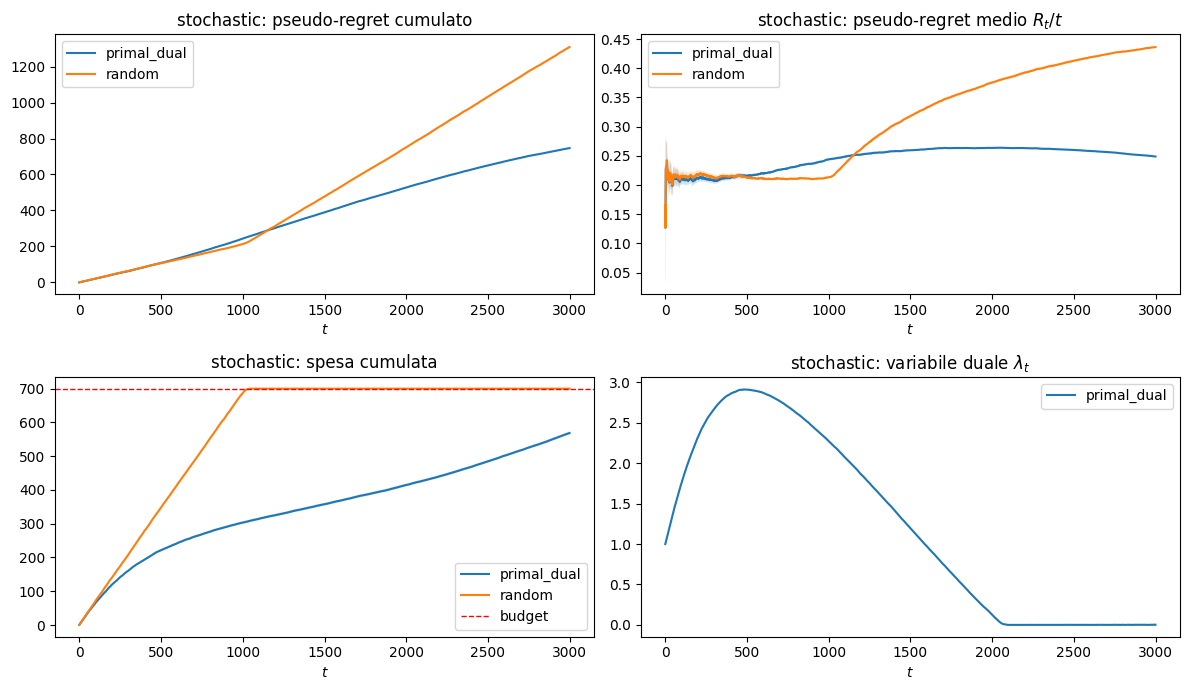

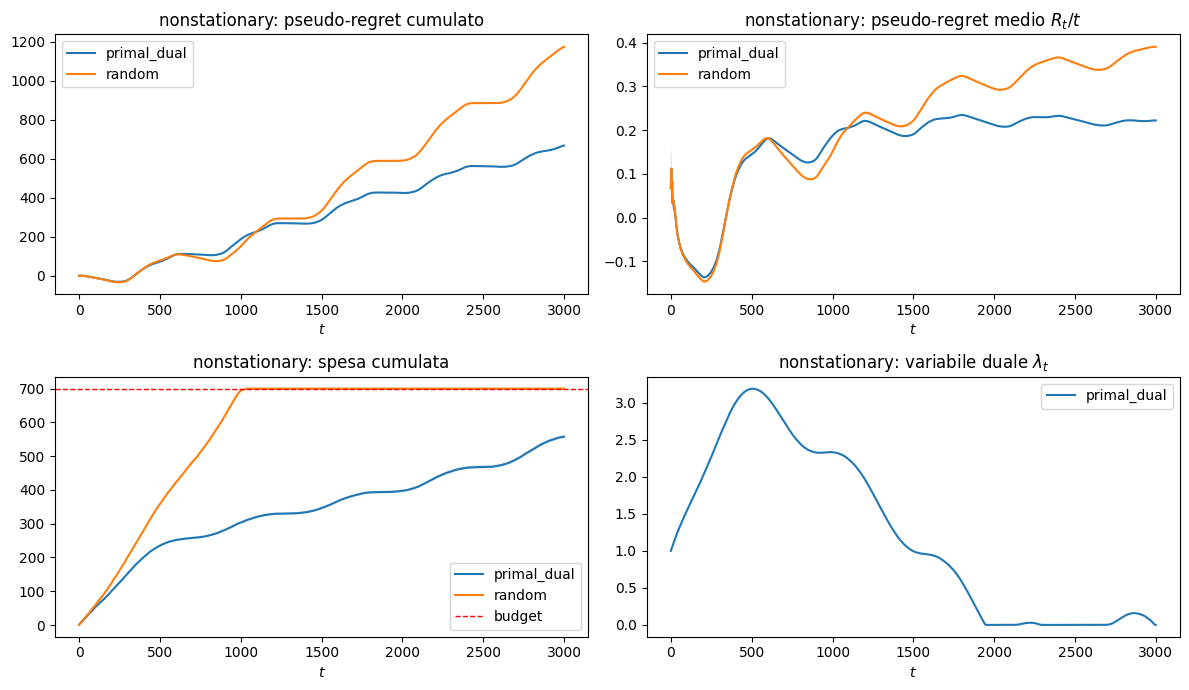

In [9]:
def plot_mean_sem(ax, data, label):
    data = np.array(data)
    mean = data.mean(axis=0)
    sem = data.std(axis=0, ddof=1) / np.sqrt(len(data))
    ax.plot(mean, label=label)
    ax.fill_between(np.arange(len(mean)), mean - sem, mean + sem, alpha=0.2)


for regime in ['stochastic', 'nonstationary']:
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    axes = axes.ravel()
    for agent_kind in ['primal_dual', 'random']:
        runs = results[regime][agent_kind]
        plot_mean_sem(axes[0], [np.cumsum(r['pseudo_regret']) for r in runs], agent_kind)
        plot_mean_sem(axes[1], [np.cumsum(r['pseudo_regret']) / np.arange(1, T + 1) for r in runs], agent_kind)
        plot_mean_sem(axes[2], [np.cumsum(r['actual_cost']) for r in runs], agent_kind)
    runs = results[regime]['primal_dual']
    plot_mean_sem(axes[3], [r['lambda'] for r in runs], 'primal_dual')
    axes[2].axhline(B, color='red', ls='--', lw=1, label='budget')
    axes[0].set_title(f'{regime}: pseudo-regret cumulato')
    axes[1].set_title(f'{regime}: pseudo-regret medio $R_t/t$')
    axes[2].set_title(f'{regime}: spesa cumulata')
    axes[3].set_title(f'{regime}: variabile duale $\\lambda_t$')
    for ax in axes:
        ax.set_xlabel('$t$')
        ax.legend()
    plt.tight_layout()
    plt.show()

## Commenti

- Il primal-dual batte nettamente il random in entrambi i regimi (regret/T 0.249 contro 0.436 nello stocastico, 0.222 contro 0.391 nel non stazionario) e non viola mai il budget.
- La spesa si ferma pero' a ~569 su 700 (e ~558 nel non stazionario): lo stop sul budget da solo non puo' spiegarlo, perche' lascia inutilizzato al piu' il costo di un round. La sotto-spesa viene dalla dinamica primal-dual: la normalizzazione della Lagrangiana con bound fissi riduce il learning rate effettivo di Hedge di un fattore ~11 e le costanti del corso sono prudenti, quindi la convergenza verso la mixture ottima e' lenta.
- E' il limite principale di questa versione: la versione migliorata cambia solo i learning rate e la regola sul budget.